In [1]:
import pandas as pd

fraud = pd.read_csv("../data/raw/Fraud_Data.csv")
ip = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [2]:
fraud['ip_address'] = fraud['ip_address'].astype(int)

In [3]:
ip = ip.sort_values('lower_bound_ip_address')
fraud = fraud.sort_values('ip_address')

In [4]:
merged = pd.merge_asof(
    fraud,
    ip,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

MergeError: incompatible merge keys [0] dtype('int64') and dtype('float64'), must be the same type

In [5]:
fraud['ip_address'] = fraud['ip_address'].astype('int64')

ip['lower_bound_ip_address'] = ip['lower_bound_ip_address'].astype('int64')
ip['upper_bound_ip_address'] = ip['upper_bound_ip_address'].astype('int64')

In [6]:
fraud = fraud.sort_values('ip_address')
ip = ip.sort_values('lower_bound_ip_address')

In [7]:
merged = pd.merge_asof(
    fraud,
    ip,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [8]:
merged = merged[
    merged['ip_address'] <= merged['upper_bound_ip_address']
]

In [9]:
merged.shape

(129146, 14)

In [10]:
merged.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,16778864,0,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,16842045,0,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,16843656,0,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,16938732,0,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,16971984,0,16941056.0,16973823.0,Thailand


In [11]:
merged['country'].isnull().sum()

np.int64(0)

In [12]:
merged['country'].isnull().mean() * 100

np.float64(0.0)

In [13]:
merged = merged.dropna(subset=['country'])

In [14]:
country_fraud_rate = merged.groupby('country')['class'].mean().sort_values(ascending=False)

country_fraud_rate.head(15)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Name: class, dtype: float64

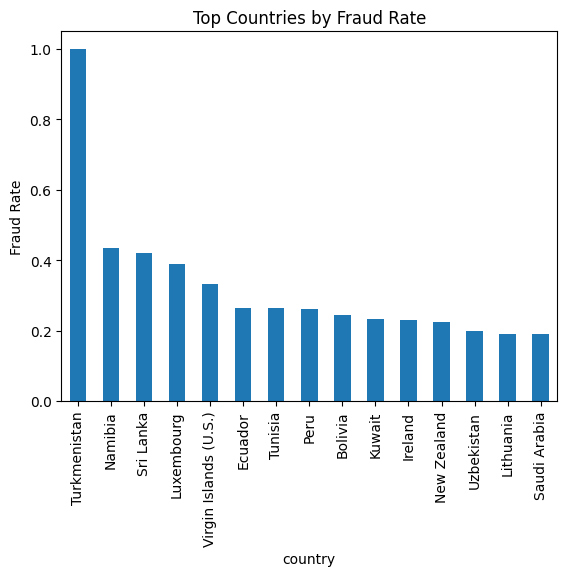

In [15]:
import matplotlib.pyplot as plt

country_fraud_rate.head(15).plot(kind='bar')
plt.title("Top Countries by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

In [16]:
model_data = merged.copy()

In [17]:
model_data = model_data.drop([
    'user_id',
    'device_id',
    'ip_address',
    'signup_time',
    'purchase_time',
    'lower_bound_ip_address',
    'upper_bound_ip_address'
], axis=1)

In [18]:
model_data.shape
model_data.head()

,purchase_value,source,browser,sex,age,class,country
634,47,SEO,Safari,F,30,0,Australia
635,15,SEO,Chrome,F,34,0,Thailand
636,44,Ads,IE,M,29,0,China
637,55,Direct,Chrome,F,30,0,China
638,51,SEO,Chrome,F,37,0,Thailand


IP-to-country mapping was successfully applied to enrich transaction data with geographic information. After merging, the dataset was cleaned and prepared for modeling by removing identifiers and keeping only predictive behavioral and contextual features. This final dataset will be used for fraud classification modeling.

In [19]:
fraud.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='object')

In [20]:
merged.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'lower_bound_ip_address', 'upper_bound_ip_address', 'country'],
      dtype='object')

In [21]:
merged['signup_time'] = pd.to_datetime(merged['signup_time'])
merged['purchase_time'] = pd.to_datetime(merged['purchase_time'])

merged['time_since_signup'] = (
    merged['purchase_time'] - merged['signup_time']
).dt.total_seconds()

merged['hour_of_day'] = merged['purchase_time'].dt.hour

merged['day_of_week'] = merged['purchase_time'].dt.dayofweek

merged['user_transaction_count'] = (
    merged.groupby('user_id')['user_id'].transform('count')
)

merged['device_transaction_count'] = (
    merged.groupby('device_id')['device_id'].transform('count')
)

In [22]:
merged.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'lower_bound_ip_address', 'upper_bound_ip_address', 'country',
       'time_since_signup', 'hour_of_day', 'day_of_week',
       'user_transaction_count', 'device_transaction_count'],
      dtype='object')

In [23]:
model_data = merged.drop([
    'user_id',
    'device_id',
    'ip_address',
    'signup_time',
    'purchase_time',
    'lower_bound_ip_address',
    'upper_bound_ip_address'
], axis=1)

In [24]:
model_data.head()

,purchase_value,source,browser,sex,age,class,country,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count
634,47,SEO,Safari,F,30,0,Australia,3632215.0,3,6,1,1
635,15,SEO,Chrome,F,34,0,Thailand,1231637.0,20,2,1,1
636,44,Ads,IE,M,29,0,China,1997534.0,23,5,1,2
637,55,Direct,Chrome,F,30,0,China,7640897.0,16,5,1,1
638,51,SEO,Chrome,F,37,0,Thailand,10249579.0,4,1,1,1


In [25]:
model_data.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

In [26]:
model_data.shape

(129146, 12)

In [27]:
model_data.columns

Index(['purchase_value', 'source', 'browser', 'sex', 'age', 'class', 'country',
       'time_since_signup', 'hour_of_day', 'day_of_week',
       'user_transaction_count', 'device_transaction_count'],
      dtype='object')